In [1]:
from transformers import AutoTokenizer
tokenizer_base = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B")
tokenizer_base.save_pretrained("Llama-3.1-8B-Base")


('Llama-3.1-8B-Base/tokenizer_config.json',
 'Llama-3.1-8B-Base/special_tokens_map.json',
 'Llama-3.1-8B-Base/tokenizer.json')

In [2]:
import os, glob
import pickle as pkl
import json
from collections import defaultdict
import re

for fname in glob.glob("./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/*"):
    print('***********Processing:',fname)
    vocab_to_merges = defaultdict(list)
    
    tokenizer_base = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B")
    
    tokenizer_json = json.load(open("Llama-3.1-8B-Base/tokenizer.json"))
    vocab_base = tokenizer_json["model"]["vocab"]
    merges_base = tokenizer_json["model"]["merges"]
    
    words_to_add = open(fname,'r',encoding='utf-8').read().splitlines()
    words_to_add = sorted(words_to_add, key=lambda x: len(x))

    for word in words_to_add:
        split = tokenizer_base.tokenize(word if not word.startswith('Ġ') else ' '+word[1:])
        
        if len(split) == 1:
            continue
        
        if len(split) == 2: #pass
            if word not in vocab_to_merges:
                vocab_to_merges[word] = [split[0],split[1]]
        
        if len(split) >= 3:
            # print('--word:',word,split)
            new_word = split[0]
            for i in range(1,len(split)):
                left = new_word
                right = split[i]
                new_word += split[i]
                # print('new_word:',new_word, 'Merge:',left,right)
                if new_word not in vocab_to_merges:
                    vocab_to_merges[new_word] = [left,right]
    
    idx = 0
    for key,val in vocab_to_merges.items():
        if key not in tokenizer_json["model"]["vocab"]:
            tokenizer_json["model"]["vocab"][key] = 128000+idx
            tokenizer_json["model"]["merges"].append(val)
            idx += 1
        
    tokenizer_json['post_processor']['processors'][-1]['special_tokens']['<|begin_of_text|>']['ids'] = [128000+idx]
    
    dump_dir = f'./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Tokenizers/SupremeCourtCase_DomainSpecific_MEDVOC_{fname.split("/")[-1][:-4]}'
    tokenizer_base.save_pretrained(dump_dir)
    
    with open(dump_dir+'/tokenizer.json', 'w',encoding='utf-8') as f:
        json.dump(tokenizer_json, f)
    f.close()


***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/5.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/80.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/10.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/90.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/20.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/30.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/100.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/60.0_.txt
***********Processing: ./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Vocab/70.0_.txt
*

In [ ]:
import regex as re
from collections import Counter
import pandas as pd


text = open('../../pretraining-files/med_Val_2K.txt','r', encoding='utf-8').read()

pre_tok = r"""(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+"""
pat = re.compile(pre_tok)

tokens = re.findall(pat, text)
tokens_dict = Counter(tokens)

list_tokens = []
list_freq = []
list_splits = []

for token, freq in tokens_dict.items():
    if len(token) < 1: continue
    len_split = len(tokenizer_base.tokenize(token))
    
    if len_split > 1:
        list_tokens.append(token)
        list_freq.append(freq)
        list_splits.append(len(tokenizer_base.tokenize(token)))
        
df = pd.DataFrame({'Word': list_tokens, 'Count': list_freq, 'Splits': list_splits})
df.to_csv('../CPT-DATA-DIR/CPT-Eval-SupremeCourtCase-SplitMoreThan1-Llama3.1.csv', index=False)

In [3]:
import pandas as pd
from transformers import AutoTokenizer
from tqdm import tqdm


df = pd.read_csv('../../data/Legal_Val_OOV_Tokens.csv')

freq_ebm = df['Count'].to_list()
terms_EBM = df['Word'].to_list()
split_bart = df['Splits'].to_list()

sum_num = 0.
sum_den = 0.
for idx,term in enumerate(terms_EBM):
    sum_num += split_bart[idx]*freq_ebm[idx]
    sum_den += freq_ebm[idx]

old_score = sum_num/sum_den


import glob
from collections import defaultdict

dict_scores = defaultdict(lambda : defaultdict(dict))
for fname in tqdm(sorted(glob.glob('./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Tokenizers/*'), key=lambda x: float(x.split('_')[-2]))): 
    # print('***********Processing:',fname, fname.split('/')[-1].split('_')[1])
    try:
        domain_tok = AutoTokenizer.from_pretrained(fname)
        
        sum_num = 0.
        sum_den = 0.
        
        for idx,term in enumerate(terms_EBM):
            sum_num += len(domain_tok.tokenize(term))*freq_ebm[idx]
            sum_den += freq_ebm[idx]

        k = int(float(fname.split('_')[-2]))
        dict_scores[f'{k}K'] = [sum_num/sum_den,len(domain_tok)]
        
    except Exception as e:
        print('Error:', e,fname)
        continue

with open(f'CPT-Eval-SupremeCourtCase-FERTILITY-VocabFiles-PostNER','a') as f:
    f.write(f'\n-------------\nCPT-SupremeCourtCase-MEDVOC-Llama3.1 []\n--------------------\n')
    f.write('Base_Tok: '+str(round(old_score,2)) + ' || ' + str(len(tokenizer_base))+'\n')
    

    for k1 in dict_scores:
        f.write(k1+'\t')
        f.write(f'{round(dict_scores[k1][0],4)} || {dict_scores[k1][1]}\t')
        f.write('\n')
f.close()


  0%|          | 0/11 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 11/11 [00:12<00:00,  1.15s/it]


In [4]:
from matplotlib import pyplot as plt

x = list(dict_scores.keys())[1:]
y = [val for val in dict_scores.values()][1:]

# x = [0]+x
# y = [[old_score,0]] + y

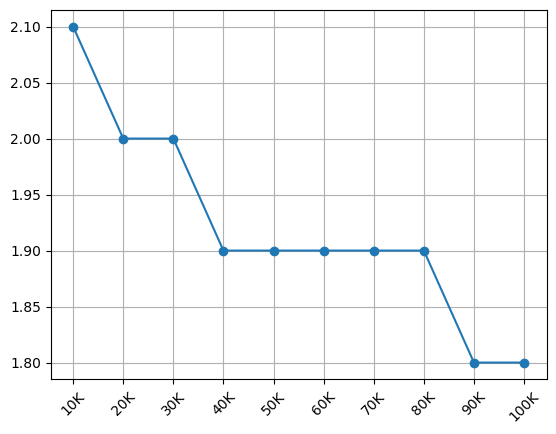

In [5]:
plt.plot(x, [round(val[0],1) for val in y], marker='o')
plt.xticks(rotation=45)
plt.grid()

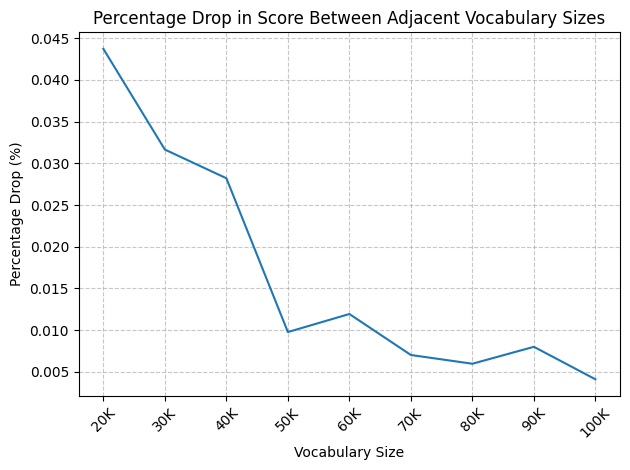

In [6]:
# Calculate percentage drop between adjacent values
x = x[:26]
y = y[:26]
percentage_drops = [(y[i][0] - y[i+1][0])/(y[i][0]) for i in range(len(y)-1)]
# Create a new figure for percentage drops
# plt.figure(figsize=(12, 6))
plt.plot(x[1:], percentage_drops)
plt.title('Percentage Drop in Score Between Adjacent Vocabulary Sizes')
plt.xlabel('Vocabulary Size')
plt.ylabel('Percentage Drop (%)')
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

In [ ]:
y[7:15], percentage_drops[7:15]

In [ ]:
idx = 0
gain_in_fragments = []
tokenizer_base = AutoTokenizer.from_pretrained("Llama-3.1-8B-Base")
tokenizer = AutoTokenizer.from_pretrained("./VocabFiles-PostNER-SupremeCourtCase/MEDICAL/MEDICAL_Vocab_Llama3_EMNLP/MEDICAL_35K_0.5_")
import numpy as np
with open('../dataset-medical/medical_domain.txt') as f:
    for line in f:
        try:
            line = line.strip()
            org_enc = tokenizer_base.encode(line)
            vocab_enc = tokenizer.encode(line)
            
            org_dec = tokenizer_base.decode(org_enc)
            vocab_dec = tokenizer.decode(vocab_enc)
            
            assert org_dec == vocab_dec, f'Failed at {idx}'
            
            gain_in_fragments.append((len(org_enc)-len(vocab_enc))/len(org_enc))
            
            idx += 1
            if idx%1000 == 0:
                print(f'Processed {idx}.... {np.percentile(gain_in_fragments, [0,10,50,90,100])}')
        except:
            print(f'--------------------Failed at {idx}--------------------')
            print(f'Orig : {org_dec}')
            print(f'Vocab: {vocab_dec}')


In [ ]:
np.percentile(gain_in_fragments, [0,10,50,90,100])

In [ ]:
import json
tokenizer = json.load(open('./PubMedQA-FromScratch-Llama3_Vocab/PubMedQA_20K_1.0_/tokenizer.json','r'))
tokenizer['model']['merges']

In [ ]:
from transformers import AutoTokenizer

tokenizer_Llama = AutoTokenizer.from_pretrained("./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Llama3.1_Tokenizers/SupremeCourtCase_DomainSpecific_MEDVOC_40.0_")
tokenizer_Qwen = AutoTokenizer.from_pretrained("./VocabFiles-PostNER/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Tokenizers/SupremeCourtCase_DomainSpecific_MEDVOC_Qwen2.5_40.0_")

tokenizer_Llama_Base = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B")
tokenizer_Qwen_Base = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")

In [ ]:
import pandas as pd
from collections import defaultdict
import regex as re
import tqdm

PRETOKENIZE_PAT = "(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\\r\\n\\p{L}\\p{N}]?\\p{L}+|\\p{N}| ?[^\\s\\p{L}\\p{N}]+[\\r\\n]*|\\s*[\\r\\n]+|\\s+(?!\\S)|\\s+"
pattern = re.compile(PRETOKENIZE_PAT)



list_oov_tokens = defaultdict(int)
list_oov_splits = defaultdict(int)

idx = 1.
with open('../../data/legal_pretrain_train_100M_tokens.txt', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            abs = line.strip()
            for token in re.findall(pattern,abs):
                sws_llama = tokenizer_Llama_Base.tokenize(token)
                sws_qwen = tokenizer_Qwen_Base.tokenize(token)
                
                if len(sws_llama) > 1 and len(sws_qwen) > 1: 
                    list_oov_tokens[token] += 1
                    list_oov_splits[token] = max(len(sws_llama), len(sws_qwen))
                    
                elif len(sws_qwen) > 1:
                    list_oov_tokens[token] += 1
                    list_oov_splits[token] = max(len(sws_llama), len(sws_qwen))

                elif len(sws_llama) > 1:
                    list_oov_tokens[token] += 1
                    list_oov_splits[token] = max(len(sws_llama), len(sws_qwen))

                else:
                    pass
            
            if idx%100 == 0:
                print(f'Processed {idx} lines.... Current OOV Tokens:{len(list_oov_tokens)}')
            
            idx += 1
        except Exception as e:
            print('Error at line:', idx, e)
            pass
            
list_oov_tokens = dict(sorted(list_oov_tokens.items(), key=lambda item: item[1], reverse=True))
list_oov_tokens


list_tokens = list(list_oov_tokens.keys())
list_splits = [list_oov_splits[token] for token in list_tokens]
list_frequencies = [list_oov_tokens[token] for token in list_tokens]

df_oov = pd.DataFrame({'Word':list_tokens, 'Splits':list_splits, 'Count':list_frequencies})
df_oov.to_csv('../../data/Legal_Train_OOV_Tokens.csv', index=False)

In [ ]:
added_vocab_Llama = [(k,v) for k,v in tokenizer_Llama.get_vocab().items() if v >= tokenizer_Llama_Base.vocab_size]
added_vocab_Qwen = [(k,v) for k,v in tokenizer_Qwen.get_vocab().items() if v >= tokenizer_Qwen_Base.vocab_size]

added_vocab_Llama = [k for k,v in sorted(added_vocab_Llama, key=lambda x: x[1])]
added_vocab_Qwen = [k for k,v in sorted(added_vocab_Qwen, key=lambda x: x[1])]

added_vocab_Llama = added_vocab_Llama[:tokenizer_Llama.vocab_size-tokenizer_Llama_Base.vocab_size]
added_vocab_Qwen = added_vocab_Qwen[:tokenizer_Qwen.vocab_size-tokenizer_Qwen_Base.vocab_size]

import tqdm
import pandas as pd

print(len(added_vocab_Llama), df_oov.shape)

# Dictionary to store results
term_stats = {}

for term in tqdm.tqdm(added_vocab_Llama):
    cleaned_term = term.replace('Ġ', ' ')
    
    mask = df_oov['Word'].str.contains(cleaned_term, regex=False, na=False)
    matches = df_oov[mask]
    
    term_stats[term] = {
        'total_count': matches['Count'].sum(),
        'num_matches': len(matches),
        'avg_count': matches['Count'].mean() if len(matches) > 0 else 0
    }

# Convert to DataFrame
results_df = pd.DataFrame.from_dict(term_stats, orient='index')
results_df = results_df.sort_values('total_count', ascending=False)

print("\nTerm statistics:")
print(results_df)

In [ ]:
results_df.to_csv('./Llama3_TermStats_AddedVocab.csv',index=False)

In [ ]:
results_df[results_df['total_count']>=283].describe()